# Marlim3 - Python Tutorials

# Gas lift

In this notebook, we continue with the base case developed in the previous tutorial, which addressed nodal analysis of flow, and perform simulations of gas injection in the production line, a procedure used in the artificial lift technique called [*gas lift*](https://en.wikipedia.org/wiki/Gas_lift). We analyze concepts such as performance curve, thermal coupling between production and service lines, and choked flow in valves.

In [1]:
%load_ext autoreload
%autoreload 2

import matplotlib.pyplot as plt
import numpy as np
import marlim3
import copy

## Introduction

Artificial lift comprises a set of techniques applied when the reservoir pressure is not sufficient for the fluid to reach the platform at the desired flow rate. Among the available methods, the most used is continuous *gas lift*, because it is simple (without rotating and vibrating mechanisms that could cause failures) and applicable to high flow rate wells. This method consists of injecting gas into the production column, with the objective of reducing the average specific mass of the fluid along the flow. This reduction minimizes the portion of pressure drop associated with hydrostatics (resistance to gravity). Since, in most conditions of interest, hydrostatic pressure drop represents the largest fraction of total flow resistance, *gas lift* results in a decrease in total pressure drop. This, in turn, reduces the bottom hole pressure and allows an increase in produced flow rate. For more details on the fundamentals of the *gas lift* technique, it is recommended to consult Chapter 6 of [ANDREOLLI (2016)](https://www.amazon.com.br/Introdu%C3%A7%C3%A3o-Eleva%C3%A7%C3%A3o-Escoamento-Monof%C3%A1sico-Multif%C3%A1sico/dp/857193388X).

In [Marlim3](https://github.com/petrobras/marlim3), there is the possibility of modeling gas injection for artificial lift purposes in two ways:

1. Using a `gasSource` type source. This is the simplest alternative, which requires only defining the gas conditions at the injection point in the production line.
2. Adding to the system a service line with a *gas lift* valve (`gasLiftSource`). This alternative is more complex and allows modeling the system in greater detail, including the *gas lift* valve, the gas properties along the flow, and the heat exchange between production and service lines. In addition, gas conditions are defined at the platform injection point.

In this tutorial we present both possibilities, starting with the simpler one.

## Importing the base case

We will import as the base case the case that was exported in the previous tutorial, about nodal analysis of flow:

In [2]:
base_case = marlim3.Branch()
base_case.from_json('base_case1_tutorials.json')

## Adding a gas source

In this section, we add a gas source to the base case to simulate injection in a simplified manner. For this, it is also necessary to define a `gasFluid` object representing the gas to be injected by the source.

In [3]:
gas_fluid = {
    "gasDensity": 0.7
}

gas_source = {
    "id": 0,
    "measuredLength": 200, #m
    "time": [0], #s
    "temperature": [87], #degC,
    "gasFlowRate": [1.5e5] #sm3/d
} 

base_case.gasFluid = gas_fluid
base_case.gasSource = [gas_source]

## Simulating!!

In [4]:
base_case.simulate()

*******************************************************************************
                                  UFA!!!!!!!!                                  
Um simulador que resolve uma parada de producao, comeca avancando pequenos incrementos de tempo
                               Confucio das simulacoes sem fim                         
*******************************************************************************
ARQUIVO DE LOG: simulacao.log



In [5]:
base_case.results['productionProfile']

Length (m) Boundary F  Length (m) Cell center C  \
Tempo (s)                                                       
0         0                       0                        50   
          1                     100                       150   
          2                     200                       250   
          3                     300                       350   
          4                     400                       450   
          5                     500                       550   
          6                     600                       650   
          7                     700                       750   
          8                     800                       850   
          9                     900                       950   
          10                   1000                      1050   
          11                   1100                      1150   
          12                   1200                      1250   
          13                   1300                      1350   
          14                   1400                      1450   
          15                   1500                      1550   
          16                   1600                      1650   
          17                   1700                      1750   
          18                   1800                      1850   
          19                   1900                      1950   
          20                   2000                      2050   
          21                   2100                      2150   
          22                   2200                      2250   
          23                   2300                      2350   
          24                   2400                      2450   
          25                   2500                      2550   
          26                   2600                      2650   
          27                   2700                      2750   
          28                   2800                      2850   
          29                   2900                      2950   

              Pressure (kgf/cm2) C  Temperature (C) C  Liquid holdup (-) C  \
Tempo (s)                                                                    
0         0             125.458058          90.000000             0.902719   
          1             117.331855          89.762225             0.908063   
          2             109.673841          89.367957             0.743805   
          3             102.700412          88.977864             0.722461   
          4              95.885841          88.562514             0.700038   
          5              89.239966          88.122241             0.676718   
          6              82.771827          87.657526             0.652457   
          7              76.490090          87.168894             0.627308   
          8              70.402421          86.656894             0.601340   
          9              64.515021          86.095336             0.574668   
          10             61.409264          85.457605             0.532246   
          11             60.993872          85.316638             0.520889   
          12             60.579596          85.176061             0.518937   
          13             60.162981          85.035820             0.516972   
          14             59.743974          84.895815             0.514987   
          15             59.322523          84.756048             0.512981   
          16             58.898574          84.616516             0.510954   
          17             58.472055          84.477223             0.508889   
          18             58.042922          84.338166             0.506819   
          19             57.611116          84.199347             0.504724   
          20             54.751405          84.060766             0.512849   
          21             49.490722          83.472319             0.499758   
          22             44.365678          82.881911        

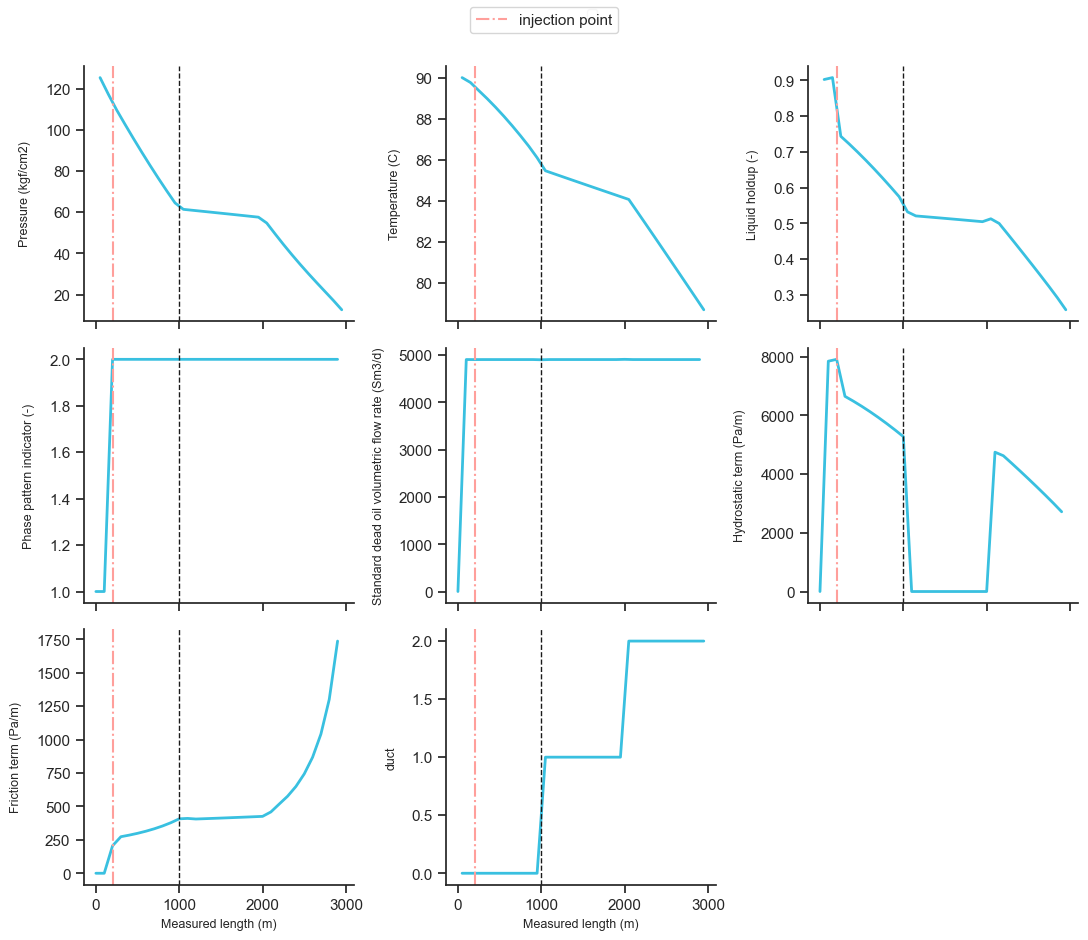

In [6]:
fig, axes = base_case.plot_profiles(indicate_anm=True)

for ax in axes:
    ax.axvline(base_case.gasSource[0]['measuredLength'], 
               c='r', label='injection point', ls='-.')

handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc='upper center');

## Try it yourself!

**1**. Compare the results presented above with the results from the base case simulation of the previous tutorial (`2-nodal_analysis.ipynb`). Identify the differences and observe how the variables behave when gas is introduced into the system.

**2**. Vary some injection parameters, such as position, flow rate, density, and temperature. Analyze the impacts of these changes on the variable profiles (tip: use the `Cenarios` class from the `marlim3` package, as demonstrated in the `1-horizontal_vertical_comparison.ipynb` tutorial).

**3**. Is there a limit to the productivity increase caused by gas injection into the system? Reflect on how this relates to the last figure we generated in the previous tutorial (`2-nodal_analysis.ipynb`).

## Production optimization

In the final exercise of the previous section, you reflected on the limit of increase in productivity due to gas injection. Now, we will explore this limit computationally, calculating the injected gas flow rate that maximizes the produced liquid flow rate. For this, we will use a numerical optimization method. This analysis is designated as the *gas lift* performance curve, used to analyze the relationship between injected gas flow rate and produced liquid flow rate, helping to identify the optimal operating point.

Let's define an objective function that accepts the gas flow rate, performs the simulation, and returns the produced liquid flow rate:

In [7]:
optimization_case = copy.deepcopy(base_case)
optimization_case.initialConfig['classicOutput'] = False

def objective_function(gas_flow_rate):

    optimization_case.gasSource[0]['gasFlowRate'] = [gas_flow_rate]
    optimization_case.simulate()

    return -optimization_case.results['productionProfile'].loc[0, 'Standard dead oil volumetric flow rate (Sm3/d) F'].iloc[-1]

The function returns the negative of the flow rate because we will use a numerical minimization method. In the next cell, we use the objective function to perform optimization and plot the result on the *gas lift* performance curve:





















































CPU times: total: 2.06 s
Wall time: 2min 3s


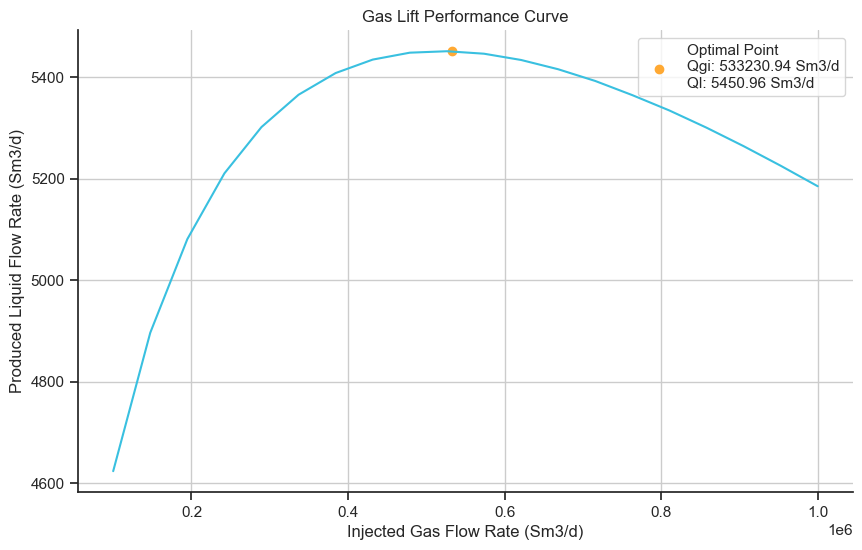

In [8]:
%%time

# importing optimizer
from scipy.optimize import minimize_scalar

# gas flow rate search interval
interval = (1e5, 1e6) #sm3/d

# optimizing
result = minimize_scalar(objective_function, bounds=interval, method='bounded')

# optimal result
optimal_gas_flow_rate = result.x
optimal_liquid_flow_rate = -result.fun

# generating points for the plot
gas_flow_rates = np.linspace(interval[0], interval[1], 20)
liquid_flow_rates = []
for gas_flow_rate in gas_flow_rates:
    optimization_case.gasSource[0]['gasFlowRate'] = [gas_flow_rate]
    optimization_case.simulate()
    produced_liquid_flow_rate = optimization_case.results['productionProfile'].loc[0, 'Standard dead oil volumetric flow rate (Sm3/d) F'].iloc[-1]
    liquid_flow_rates.append(produced_liquid_flow_rate)

# plotting the objective function and the optimal point
plt.figure(figsize=(10, 6))
plt.plot(gas_flow_rates, liquid_flow_rates, color='#39C0E0')
plt.scatter(optimal_gas_flow_rate, optimal_liquid_flow_rate, color='#FFA933', label=f"Optimal Point\nQgi: {optimal_gas_flow_rate:.2f} Sm3/d\nQl: {optimal_liquid_flow_rate:.2f} Sm3/d")
plt.xlabel("Injected Gas Flow Rate (Sm3/d)")
plt.ylabel("Produced Liquid Flow Rate (Sm3/d)")
plt.title("Gas Lift Performance Curve")
plt.legend()
plt.grid()

Note that, from the optimal point onwards, an increase in injected gas flow rate results in a reduction in produced liquid flow rate. This occurs because, with high gas flow rates, the increase in the friction term of pressure drop is so significant that it exceeds the reduction in the hydrostatic term.

In practice, several additional factors influence the definition of the operating point, such as costs associated with gas compression, gas availability in the consumer market, and difficulties related to its export. Thus, the point of greatest economic return may not coincide with the point of greatest produced liquid flow rate. For more details, consult [ANDREOLLI (2016)](https://www.amazon.com.br/Introdu%C3%A7%C3%A3o-Eleva%C3%A7%C3%A3o-Escoamento-Monof%C3%A1sico-Multif%C3%A1sico/dp/857193388X).

## Try it yourself!

**1.** Plot several *gas lift* performance curves on the same graph, varying parameters such as BSW and line diameter.

## Adding service line and *gas lift* valve

The approach presented in the previous section is sufficient for simple studies related to increasing well productivity through gas injection. However, for a more detailed representation of the physical phenomena associated with gas injection, it is necessary to add a service line and a *gas lift* valve (VGL) to the model.

The first step for this is to deactivate the gas source placed earlier:

In [9]:
base_case_vgl = copy.deepcopy(base_case)

base_case_vgl.gasSource[0]['active'] = False

### Updating the production line

#### Adding new cross-section for the well section without coupling

The service line extends from the platform to the injection point, where the VGL is located. Below this point, there is no service line, and consequently, the cross-section of the well in this region will consist of only one layer. Thus, it will be necessary to add one more element to the `crossSection` vector, representing the corresponding cross-section for this area.

Let's visualize how the set of cross-sections is currently:

In [10]:
base_case_vgl.display_table('crossSection')

Let's copy the first section, corresponding to the well, and keep only the first layer, corresponding to the internal steel layer:

In [11]:
well_production_cross_section_2 = copy.deepcopy(base_case_vgl.crossSection[0])

well_production_cross_section_2['id'] = 2
well_production_cross_section_2['label'] = 'Well cross-section - uncoupled section'
well_production_cross_section_2['layer'] = [well_production_cross_section_2['layer'][0]]

base_case_vgl.crossSection.append(well_production_cross_section_2)

#### Adding new production duct for the well section without coupling

With the cross-section already available, we can create a new production duct for the section between the bottom of the well and the VGL. In addition, it will be necessary to update the other well section (between the VGL and the seabed) for the new configurations.

Let's visualize how the set of production ducts is currently:

In [12]:
base_case_vgl.display_table('productionPipe')

What we need to do is:

- split the well duct into two other ducts, one from 0 to 200 m corresponding to the section without coupling (from the bottom of the well to the VGL) and the other from 200 to 800 m corresponding to the section coupled to the service line (from the VGL to the seabed);

- turn on thermal coupling in the corresponding section;

- modify the environmental conditions (external temperature) in the section without coupling. In the case of the coupled section, environmental conditions must be informed in the service line, not in the production line.

The most complicated part is configuring the environmental conditions, both in the production line and in the service line, to correspond to what was specified in the base case without service line. To help with this task, we define a function that returns the formation temperature to respect what was specified in the previous case:

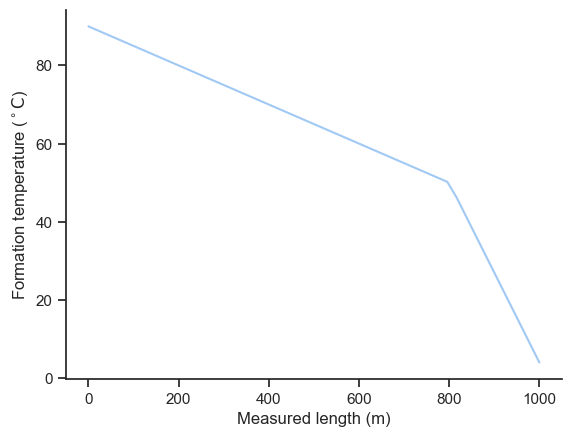

In [13]:
def well_ambient_temperature(x):
    if x<=800:
        return -.05*x+90
    else:
        #return -0.23*x + 234
        return 50-.23*(x-800)

X = np.linspace(0,1000)

plt.plot(X,[well_ambient_temperature(x) for x in X]);
plt.xlabel('Measured length (m)')
plt.ylabel(r'Formation temperature ($^\circ\mathrm{C}$)');

With that done, we can define the section without coupling (between 0 and 200m) and add it to the list of production ducts (in the first position, according to the filling order, which follows the direction of flow):

In [14]:
uncoupled_production_duct = {
  'id': 3,
  'label': 'Well - uncoupled section',
  'crossSectionId': 2, # new cross-section defined above, containing only the inner steel layer
  'formationId': 0, # original formation
  'angle': np.pi/2,
  'discretization': [{'numCells': 2, 'length': 100}]}

uncoupled_production_duct['initialConditions'] = {'measuredPosition': [0,1], 'ambientTemp': [well_ambient_temperature(0), well_ambient_temperature(200)]}

base_case_vgl.productionPipe.insert(0, uncoupled_production_duct)

The next step is to modify the second duct to have a length of 800 m and consider thermal coupling:

In [15]:
base_case_vgl.productionPipe[1]['discretization'] = [{'numCells': 8, 'length': 100}]

base_case_vgl.productionPipe[1]['thermalCoupling'] = 1
del base_case_vgl.productionPipe[1]['formationId']

Now our list of production ducts is ready:

In [16]:
base_case_vgl.display_table('productionPipe')

### Adding service line

The service line will consist of three ducts, corresponding to the well, flowline, and riser sections, similar to the production line. However, there are two important differences:

- the filling order in the service line is from the platform to the well (following the direction of injection flow);
- the last service duct, corresponding to the well section, will have annular geometry, coupled to the first production duct.

The first step is to activate the service line in `initialConfig`:

In [17]:
base_case_vgl.initialConfig['gasLine'] = True

Now let's define the cross-sections that will compose these ducts. For the annular cross-section, it will be necessary to define the internal and external diameters based on information from the original well cross-section:

In [18]:
inner_diameter_column = base_case.crossSection[0]['innerDiameter']

# annulus inner diameter
# column inner diameter plus twice the radial thickness of the first steel layer
inner_diameter_annulus = inner_diameter_column + 2 * base_case.crossSection[0]['layer'][0]['thickness'] 

# annulus outer diameter
# annulus inner diameter plus twice the radial thickness of the second layer (completion fluid),
# which corresponds to the annulus flow region in the service duct
outer_diameter_annulus = inner_diameter_annulus + 2 * base_case.crossSection[0]['layer'][1]['thickness']

With the layers defined, we can create the cross-sections:

In [19]:
service_cross_section_flowline_riser = {
    "id": 3,
    'label': 'Flowline+riser cross-section [SERVICE]',
    "innerDiameter": 5*0.0254, #m
    "roughness": 0.183e-3, #m
    "layer": base_case.crossSection[1]['layer'] # 1'' steel + 1'' insulation, defined in the previous nodal analysis tutorial
}

service_cross_section_well = {
    "id": 4,
    'label': 'Well cross-section [SERVICE]',
    "annular": True,
    "innerDiameter": inner_diameter_annulus, #m
    "outerDiameter": outer_diameter_annulus, #m
    "roughness": 0.183e-3, #m
    "layer": base_case.crossSection[0]['layer'][-2:]
}

base_case_vgl.crossSection.append(service_cross_section_flowline_riser)
base_case_vgl.crossSection.append(service_cross_section_well)

With the cross-sections defined, we can create the three corresponding ducts:

In [20]:
ncel = 10

comprimento_total = 1000 #m

discretization = {
    "numCells": ncel,
    "length": comprimento_total/ncel #m
}

riser_sea_conditions = {
          "measuredPosition": [0, 1],
          "ambientTemp": [20, 4], #degC
          "ambientVel": [1, 0.1], #m/s

}

service_riser = {
        "id": 0,
        "label": "Riser [SERVICE]",
        "crossSectionId": 3, # flowline+riser cross-section defined earlier
        "environment": 1, # seawater
        "angle": -np.pi/2, #rad
        "discretization": [discretization], # discretization defined above
        "initialConditions": riser_sea_conditions, # conditions defined above
        "thermalCoupling": 0 # no coupling

}

In [21]:
ncel = 10

comprimento_total = 1000 #m

discretization = {
    "numCells": ncel,
    "length": comprimento_total/ncel #m
}

seabed_conditions = {
          "measuredPosition": [0, 1],
          "ambientTemp": [4, 4], #degC
          "ambientVel": [0.1, 0.1], #m/s

}

service_flowline = {
        "id": 1,
        "label": "Flowline [SERVICE]",
        "crossSectionId": 3, # flowline+riser cross-section defined earlier
        "environment": 1, # seawater
        "angle": 0, #rad
        "discretization": [discretization], # discretization defined above
        "initialConditions": seabed_conditions, # conditions defined above
        "thermalCoupling": 0 # no coupling
}

In [22]:
ncel = 10

comprimento_total = 1000-200 #m

discretization = {
    "numCells": ncel,
    "length": comprimento_total/ncel #m
}

service_formation_conditions = {
          "measuredPosition": [0, 200/800, 1], 
          "ambientTemp": [4, 50, well_ambient_temperature(200)] #degC #90-(200/800)*(90-50)]
}

service_annulus = {
        "id": 2,
        "label": "Well annulus [SERVICE]",
        "crossSectionId": 4, 
        "formationId": 0, # formation id defined earlier
        "angle": -np.pi/2, #rad; negative because it flows downward
        "discretization": [discretization], # discretization defined above
        "initialConditions": service_formation_conditions, # conditions defined above
        "thermalCoupling": 1 # with coupling
} 

With the three ducts defined, we can add them to the `servicePipe` field:

In [23]:
base_case_vgl.servicePipe = [service_riser, service_flowline, service_annulus]

Visualizing the service ducts table:

In [24]:
base_case_vgl.display_table('servicePipe')

Visualizing the geometry:

In [25]:
base_case_vgl.plot_geometry()

### *Gas lift* valve

The *gas lift* valve must be defined in the `gasLiftSource` object. We will first use an orifice valve, then compare it with a Venturi valve.

In [26]:
vgl = {
      "id": 0,
      "prodMeasuredLength": 200, #m
      "serviceMeasuredLength": 2800, #m
      "valveType": 0, #orifice
      "orificeDiameter": 0.005, #m
      "recoveryFactor": 0.0,
      "areaRatio": 0.1
}

base_case_vgl.gasLiftSource = [vgl]

### Boundary condition for gas injection

It is also necessary to define the boundary conditions for gas injection at the platform compressor:

In [27]:
gas_injection_bc = {
      "bcType": 1, # injection flow rate
      "time": [0], #s
      "temperature": [40], #degC
      "gasFlowRate": [1.5e5], #sm3/d
}

base_case_vgl.gasInj = gas_injection_bc

### Simulation output specification for service line

In [28]:
service_output_vars = ["pressure", 
                       "temperature",
                       "hydro",
                       "fric"
                  ] 

service_output = {"time": [0]} | {var: True for var in service_output_vars}

base_case_vgl.serviceProfile = service_output

## Specifying case with strong coupling between lines in the annulus

Thermal coupling between production and service lines is not usually well represented by flow models in the vicinity of the Christmas tree, due to numerical problems arising from the marching nature of the method for solving steady-state profiles. To resolve this limitation, one can opt to perform a pseudo-transient of the energy equation to capture in more detail the heat exchange phenomenon resulting from thermal coupling between lines. In [Marlim3](https://github.com/petrobras/marlim3), this option can be selected in the `strongAnnularColCoupling` field in `initialConfig.advanced`, which specifies the number of pseudo-transient resolution steps:

In [29]:
strong_coupling_case = copy.deepcopy(base_case_vgl)

strong_coupling_case.initialConfig['advanced'] = {}
strong_coupling_case.initialConfig['advanced']['strongAnnularColCoupling'] = 20

### Simulating!!

Phew! As we can see, the introduction of the service line brings several additional complexities to the model. But now everything is ready and we can simulate!

In [30]:
%%time

base_case_vgl.simulate()

*******************************************************************************
                                  UFA!!!!!!!!                                  
                  A necessidade e a mae da inovacao, mas a paciencia e o pai    
                                      Marcao da Oficina                                 
*******************************************************************************
ARQUIVO DE LOG: simulacao.log

CPU times: total: 109 ms
Wall time: 3.55 s


In [31]:
%%time
strong_coupling_case.simulate()

*******************************************************************************
                                  UFA!!!!!!!!                                  
      So nos curamos de um sofrimento depois de o haver suportado ate o fim.    
                                Marcel Proust no CrossFit                               
*******************************************************************************
ARQUIVO DE LOG: simulacao.log

CPU times: total: 31.2 ms
Wall time: 2.85 s


Creating a `Scenarios` object to make comparisons:

In [32]:
source_comparison = marlim3.Scenarios({'using gasSource': base_case, 'using gasLiftSource': base_case_vgl,
                                     'using gasLiftSource strong coupling': strong_coupling_case})

Visualizing the results:

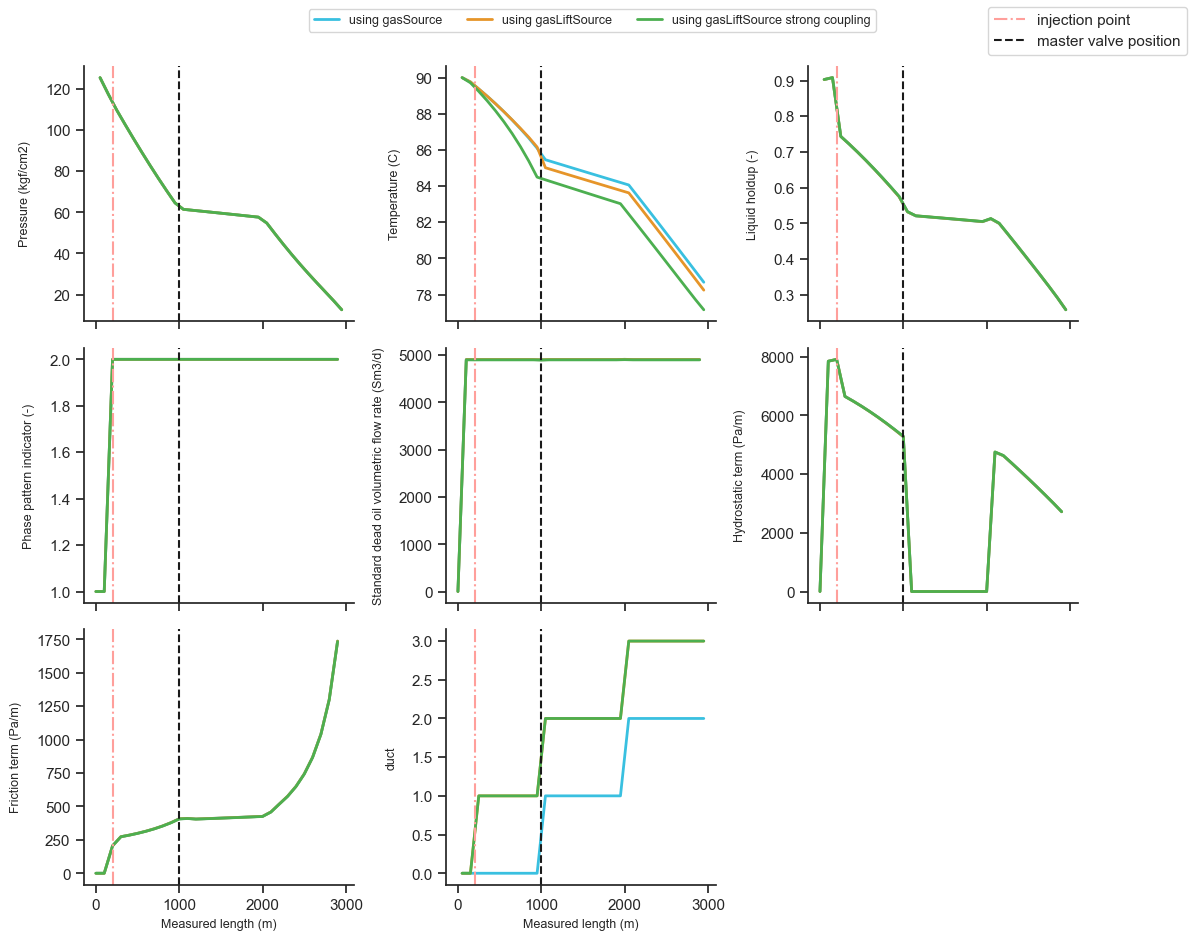

In [33]:
fig, axes = source_comparison.plot_profiles()

for ax in axes:
    injection = ax.axvline(base_case.gasSource[0]['measuredLength'], c='r', label='injection point', ls='-.')
    anm = ax.axvline(base_case.masterValve['measuredLength'], c='k', label='master valve position', ls='--')

fig.legend([injection, anm], ['injection point', 'master valve position'], loc='upper right');

Note that, in general, the profiles are very similar in the three cases analyzed, which indicates that the simplified approach of considering a gas source, instead of including the service line with valve, is adequate. However, the temperature profile in the case where the service line and strong thermal coupling between the column and the annular space are considered shows a significant difference. Therefore, strong thermal coupling calculation should be performed in scenarios where accurate prediction of the temperature profile is important, especially in the vicinity of the Christmas tree.

We can also compare the profiles in the service line:

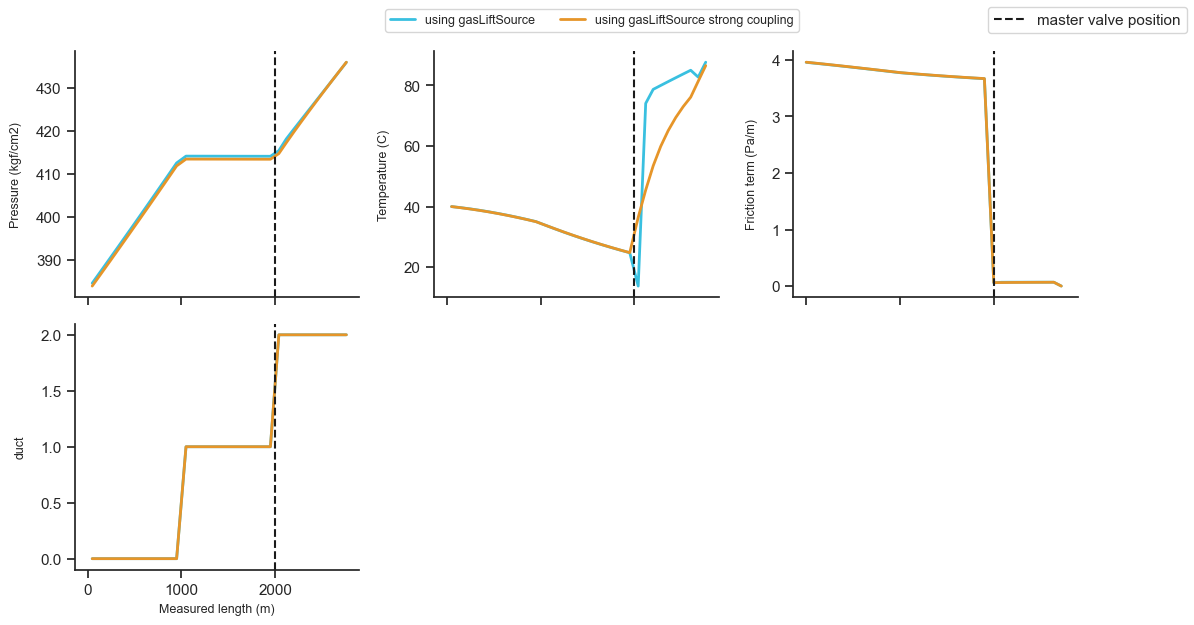

In [34]:
service_source_comparison = marlim3.Scenarios({'using gasLiftSource': base_case_vgl,
                                             'using gasLiftSource strong coupling': strong_coupling_case})

fig, axes = service_source_comparison.plot_profiles(line='service')

for ax in axes:
    anm = ax.axvline(2000, c='k', label='master valve position', ls='--')

fig.legend([anm], ['master valve position'], loc='upper right');

Notice how the case using strong thermal coupling results in a smoother rise in gas temperature in the service line, in a more accurate representation of the physical phenomenon.

## Analyzing impact of *gas lift* valve type

In the examples we analyzed so far, an orifice type valve was used, which works using a classic convergent nozzle model. [Marlim3](https://github.com/petrobras/marlim3) also enables the use of Venturi type valves, which uses a convergent-divergent model. This introduces advantages due to changes in the operating condition in which critical flow occurs at the valve throat. The following figure demonstrates the difference between the two geometries. For more details, consult [ALMEIDA (2020)](https://www.semanticscholar.org/paper/VENTURI-GAS-LIFT-VALVE%3A-THEORY-AND-PRACTICE-Almeida/1cf384fe8aa7755336acbebb91f563f0c35a7522).

<div style="text-align: center;">
    <img src="https://figures.semanticscholar.org/1cf384fe8aa7755336acbebb91f563f0c35a7522/4-Figure3-1.png" alt="Alternative text" width="400" height="300">
</div>

In critical flow, the flow velocity in a given region becomes equal to the speed of sound propagation. When this condition is reached, the flow is said to be choked. The consequence is that pressure information does not propagate downstream to upstream of the considered region. In this way, any change in downstream pressure (for example, decrease in its value) is not perceived by the upstream flow condition.

Considering a *gas lift* valve, there is a critical flow condition defined by the critical ratio between upstream pressure (annulus) and downstream pressure (valve throat), resulting from thermodynamic relationships. In the orifice valve, due to its geometry, in the critical flow condition this ratio is practically equal to the pressure ratio in the annulus and in the column. This occurs because there is no relevant pressure recovery from the valve throat to the column.

The magic of the Venturi valve is based precisely on this point: enabling in the diffuser region (divergent geometry) a pressure recovery, making the pressure ratio in the column and in the annulus at which the critical condition occurs at the throat greater than the ratio dictated by thermodynamics. That is, for the same pressure in the annulus, the column pressure necessary to reach the critical (maximum) flow rate will be higher compared to the orifice valve. Similarly, the annulus pressure of the Venturi valve for the same column pressure, compared to the orifice valve, will be lower. This last effect is what will be visualized in the next simulation.

In [35]:
orifice_case = copy.deepcopy(base_case_vgl)
venturi_case = copy.deepcopy(base_case_vgl)

venturi_case.gasLiftSource[0]['valveType'] = 2 # venturi

venturi_case.simulate()

orifice_venturi_comparison = marlim3.Scenarios({'orifice': orifice_case, 'venturi': venturi_case})

*******************************************************************************
                                  UFA!!!!!!!!                                  
                            Nada e permanente, exceto a mudanca                           
          Heraclito de Efeso vendo tudo mudar a cada incremento de tempo                
*******************************************************************************
ARQUIVO DE LOG: simulacao.log



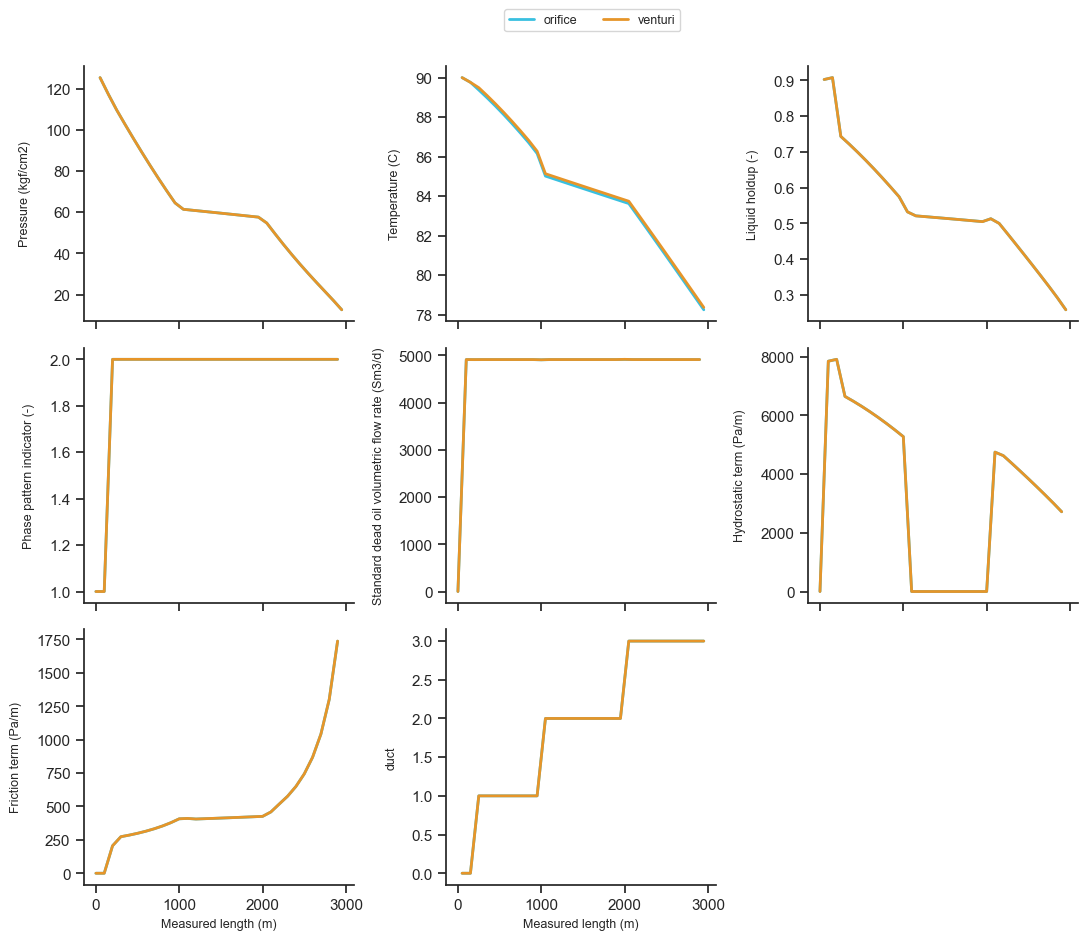

In [36]:
marlim3.Scenarios({'orifice': orifice_case, 'venturi': venturi_case}).plot_profiles();

No changes in the production line profiles. But when observing the service line...

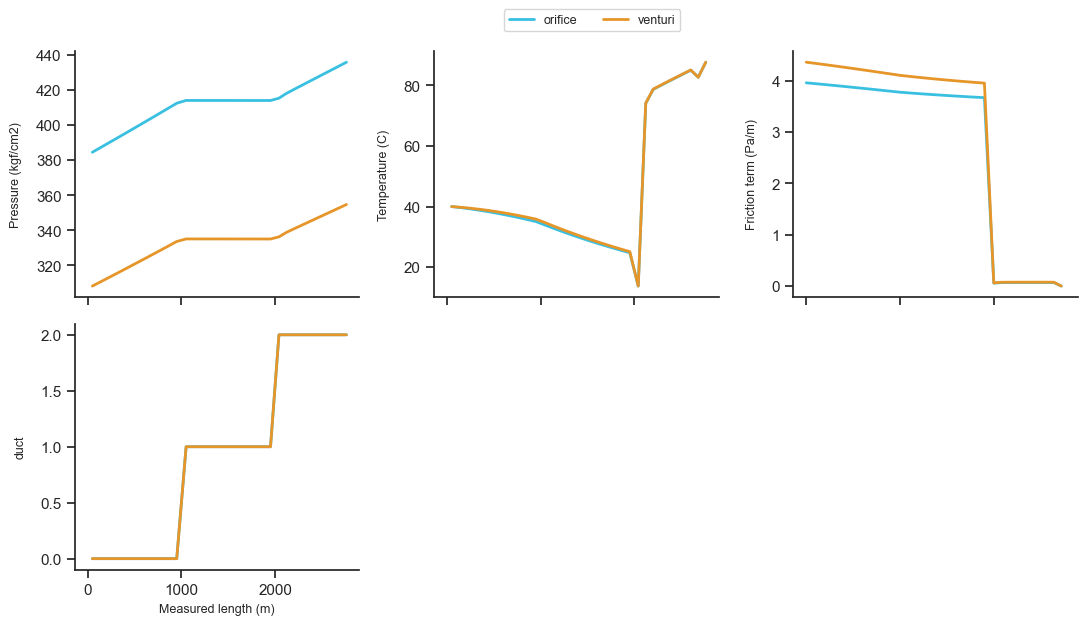

In [37]:
marlim3.Scenarios({'orifice': orifice_case, 'venturi': venturi_case}).plot_profiles(line='service');

The annulus pressure in the case with Venturi valve, associated with the same production condition, is significantly lower! This means that the two cases have critical flow at the valve throat, and in the case of the Venturi valve, this condition is reached with lower injection pressure. Therefore, less energy is spent in the gas injection system to achieve the same performance.

## Saving the base case

In the command below, we save the base case in a JSON to be able to import it in the next tutorial.

In [38]:
base_case_vgl.to_json('base_case_vgl_tutorials')

## Try it yourself!!

1. Change the gas injection boundary condition in the `venturi_case` model, replacing the flow-rate boundary condition with a pressure boundary condition. To do so, modify the parameters of the `gasInj` object. Use as injection pressure the value obtained in the previous simulation, which used the flow-rate boundary condition. Check whether the resulting flow rate is equal to the one defined earlier, as expected. Then compare the execution times of the two simulations. Are they different? Why?

2. Repeat the same procedure using the `orifice_case` model, while still using the injection pressure from the Venturi-valve case. Is the resulting flow rate greater or smaller than the one obtained in the previous item? Why?